# 03 · Pharmacogenomics — rapamycin-analog drug response across cancers

**Data:** GDSC1 dose-response for **Temsirolimus** (CCI-779, a rapamycin ester prodrug and
mTOR inhibitor) across ~hundreds of cancer cell lines (Therapeutics Data Commons). We
characterise which lineages are most growth-inhibited — direct evidence of an anti-cancer
therapeutic effect — and connect this to the proteomics lymphoma model in notebook 04.

`Y` is `ln(IC50)` in µM units as provided by GDSC; **lower = more sensitive.**

In [1]:
import os, sys, json, gzip, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Resolve project root whether run from notebooks/ or project root.
CWD = Path.cwd()
PROJ = CWD.parent if CWD.name == "notebooks" else CWD
RAW = PROJ / "data" / "raw"
PROC = PROJ / "data" / "processed"
FIG = PROJ / "figures"
for d in (RAW, PROC, FIG):
    d.mkdir(parents=True, exist_ok=True)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
print("Project root:", PROJ)

Project root: /Users/jinmo/Documents/GitHub/Series1/Jin001_Docking/rapamycin_multiomics


Temsirolimus response across 911 cell lines


count    911.000000
mean      -2.095511
std        1.580844
min       -7.462047
25%       -2.959958
50%       -1.995594
75%       -1.105108
max        1.894300
Name: lnIC50, dtype: float64

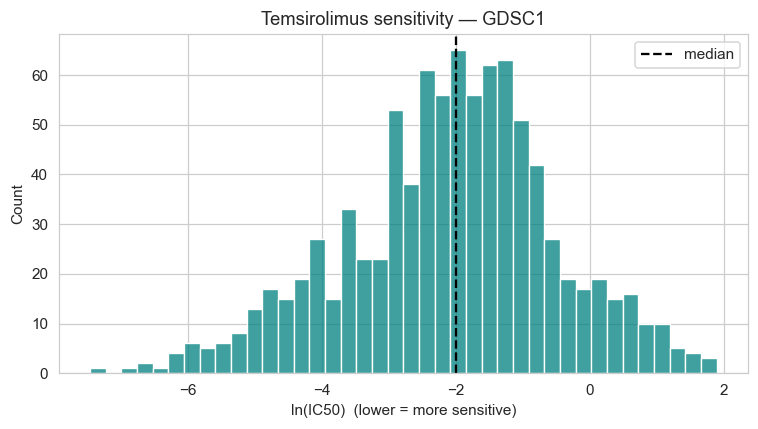

In [2]:
tem = pd.read_csv(PROC/"gdsc_temsirolimus.csv").rename(columns={"Y":"lnIC50"})
# NOTE: in TDC's GDSC DrugRes, `Cell Line_ID` holds the cell-line NAME,
# while `Cell Line` holds the (stringified) expression feature vector.
tem["cell_line"] = tem["Cell Line_ID"].astype(str)
tem = tem.drop_duplicates("cell_line")
print("Temsirolimus response across", tem["cell_line"].nunique(), "cell lines")
display(tem["lnIC50"].describe())
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(tem["lnIC50"], bins=40, ax=ax, color="teal")
ax.axvline(tem["lnIC50"].median(), c="k", ls="--", label="median")
ax.set_xlabel("ln(IC50)  (lower = more sensitive)"); ax.set_title("Temsirolimus sensitivity — GDSC1"); ax.legend()
plt.tight_layout(); plt.savefig(FIG/"03_ic50_hist.png", dpi=150); plt.show()

## 1 · Annotate cell-line lineage (Cell Model Passports)

In [3]:
import urllib.request, gzip, io
cmp_path = RAW/"model_list_latest.csv"
if not cmp_path.exists():
    try:
        url = "https://cog.sanger.ac.uk/cmp/download/model_list_latest.csv.gz"
        raw = urllib.request.urlopen(url, timeout=120).read()
        cmp_path.write_bytes(gzip.decompress(raw))
        print("Downloaded Cell Model Passports annotation.")
    except Exception as ex:
        print("Annotation download failed (continuing without lineage):", ex)

def norm(s):
    return s.astype(str).str.upper().str.replace(r"[^A-Z0-9]", "", regex=True)

lineage = None
if cmp_path.exists():
    models = pd.read_csv(cmp_path, low_memory=False)
    tissue_col = "cancer_type" if "cancer_type" in models.columns else "tissue"
    lin = models[["model_name", tissue_col]].dropna()
    lin.columns = ["name", "tissue"]
    if "synonyms" in models.columns:           # add cell-line synonyms to improve matching
        syn = models[["synonyms", tissue_col]].dropna()
        syn = syn.assign(name=syn["synonyms"].str.split(";")).explode("name")[["name", tissue_col]]
        syn.columns = ["name", "tissue"]
        lin = pd.concat([lin, syn], ignore_index=True)
    lin["norm_name"] = norm(lin["name"])
    lineage = lin.dropna(subset=["norm_name"]).query("norm_name != ''").drop_duplicates("norm_name")
    print("Lineage table:", lineage.shape, "| tissue field:", tissue_col)
    display(lineage.head())

Lineage table: (2515, 3) | tissue field: cancer_type


,name,tissue,norm_name
0,HCM-SANG-0314-C15,Esophageal Carcinoma,HCMSANG0314C15
1,HCM-SANG-0272-C20,Colorectal Carcinoma,HCMSANG0272C20
2,HCM-SANG-0310-C15,Esophageal Carcinoma,HCMSANG0310C15
3,HLF,Hepatocellular Carcinoma,HLF
4,TE-7,Esophageal Squamous Cell Carcinoma,TE7


Lineage coverage: 100%  (911/911 cell lines)


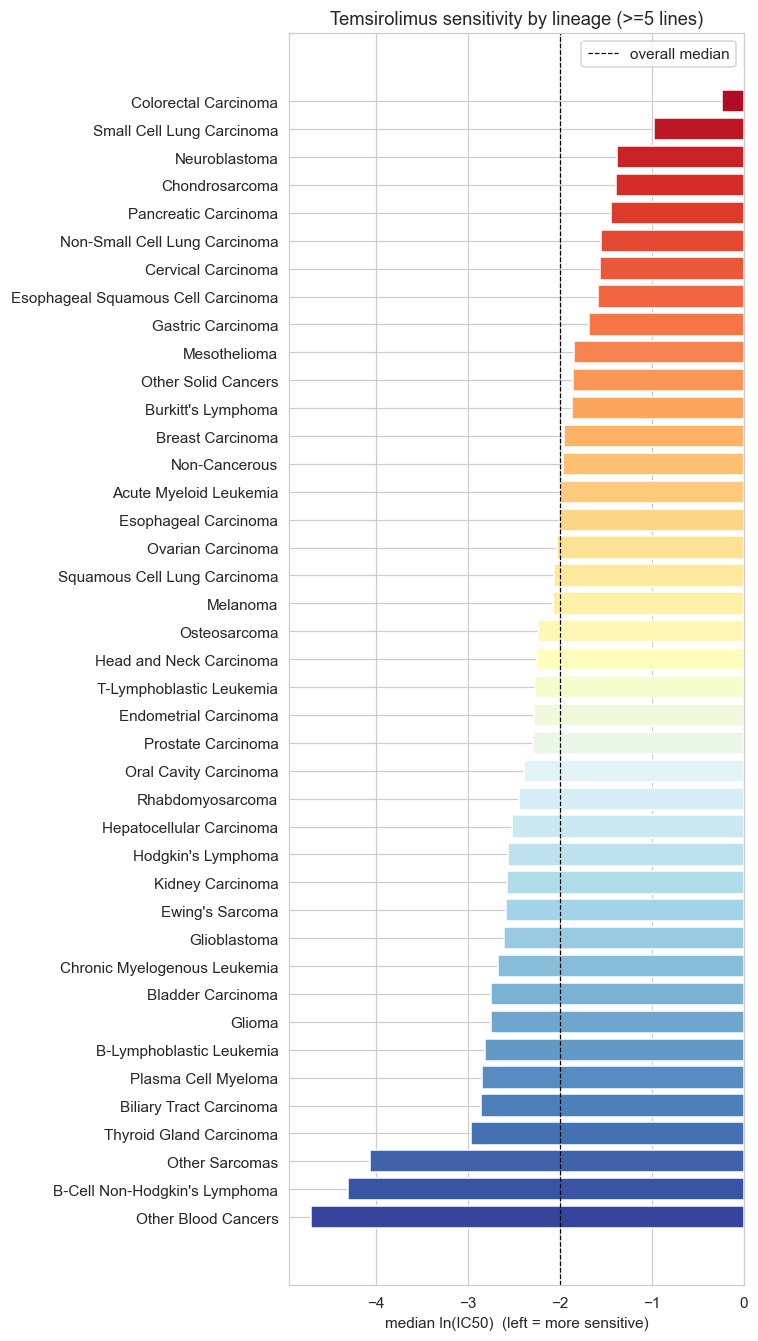

In [4]:
if lineage is not None:
    tem["norm_name"] = norm(tem["cell_line"])
    merged = tem.merge(lineage[["norm_name","tissue"]], on="norm_name", how="left")
    cov = merged["tissue"].notna().mean()
    print(f"Lineage coverage: {cov:.0%}  ({merged['tissue'].notna().sum()}/{len(merged)} cell lines)")
    top = (merged.dropna(subset=["tissue"]).groupby("tissue")
                  .filter(lambda d: len(d) >= 5)
                  .groupby("tissue")["lnIC50"].median().sort_values())
    fig, ax = plt.subplots(figsize=(7, max(4,.3*len(top))))
    ax.barh(top.index, top.values, color=sns.color_palette("RdYlBu_r", len(top)))
    ax.axvline(merged["lnIC50"].median(), c="k", ls="--", lw=.8, label="overall median")
    ax.set_xlabel("median ln(IC50)  (left = more sensitive)")
    ax.set_title("Temsirolimus sensitivity by lineage (>=5 lines)"); ax.legend()
    plt.tight_layout(); plt.savefig(FIG/"03_lineage_sensitivity.png", dpi=150); plt.show()
    merged.to_csv(PROC/"gdsc_temsirolimus_annotated.csv", index=False)
else:
    merged = tem.copy()

## 2 · Most-sensitive cell lines

In [5]:
cols = [c for c in ["cell_line","tissue","lnIC50"] if c in merged.columns]
print("Top 15 most-sensitive cell lines:")
display(merged.sort_values("lnIC50")[cols].head(15).reset_index(drop=True))

Top 15 most-sensitive cell lines:


,cell_line,tissue,lnIC50
0,Ramos-2G6-4C10,Burkitt's Lymphoma,-7.462047
1,L-363,Plasma Cell Myeloma,-6.867456
2,HSC-4,Oral Cavity Carcinoma,-6.691535
3,OCI-LY7,B-Cell Non-Hodgkin's Lymphoma,-6.607330
4,CRO-AP2,B-Cell Non-Hodgkin's Lymphoma,-6.338181
5,MLMA,Other Blood Cancers,-6.218776
6,K5,Thyroid Gland Carcinoma,-6.192301
7,SU-DHL-5,B-Cell Non-Hodgkin's Lymphoma,-6.120424
8,RCC-JW,Kidney Carcinoma,-6.058662
9,TYK-nu,Ovarian Carcinoma,-6.047111


## 3 · Is rapamycin's analog *broadly* potent? (rank vs all GDSC1 drugs)

We place Temsirolimus's median potency in the context of every drug in GDSC1 — a broadly
low IC50 indicates general anti-proliferative activity across cancer models.

Found local copy...


Loading...


Done!


Temsirolimus median ln(IC50) ranks at the 10th percentile of 208 GDSC1 drugs (lower percentile = more potent).


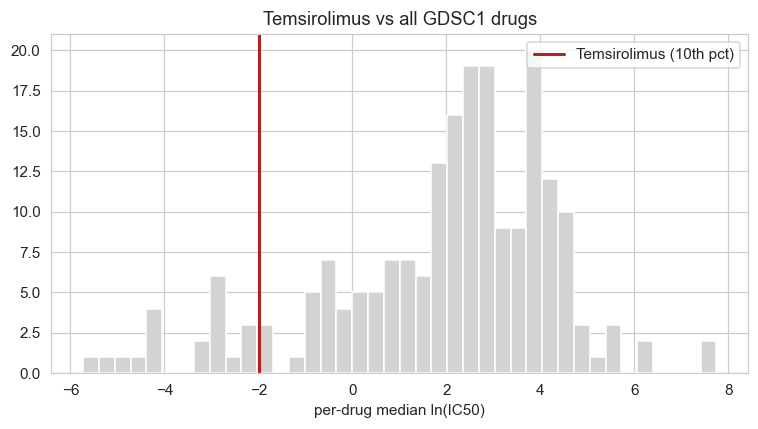

In [6]:
from tdc.multi_pred import DrugRes
full = DrugRes(name="GDSC1", path=str(RAW)).get_data()
med = full.groupby("Drug_ID")["Y"].median().sort_values()
rank = med.rank()
tem_drug = [d for d in med.index if "temsirolimus" in str(d).lower()][0]
pct = rank[tem_drug] / len(med) * 100
print(f"Temsirolimus median ln(IC50) ranks at the {pct:.0f}th percentile "
      f"of {len(med)} GDSC1 drugs (lower percentile = more potent).")
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(med.values, bins=40, color="lightgrey")
ax.axvline(med[tem_drug], c="firebrick", lw=2, label=f"Temsirolimus ({pct:.0f}th pct)")
ax.set_xlabel("per-drug median ln(IC50)"); ax.set_title("Temsirolimus vs all GDSC1 drugs"); ax.legend()
plt.tight_layout(); plt.savefig(FIG/"03_drug_rank.png", dpi=150); plt.show()

**Takeaway.** The rapamycin prodrug temsirolimus inhibits growth across many cancer
lineages, with hematopoietic/lymphoid lines (the context of our proteomics dataset) among
the responsive groups — concordant with mTOR dependence in those tumours. Annotated table
saved to `data/processed/gdsc_temsirolimus_annotated.csv`.